# Instrument-free AltAz sky-brightness map

This example computes rectangular maps of the night-sky photon radiance in local
altitude and azimuth. It deliberately stops **before** an instrument model:
there are no camera pixels, effective aperture, or telescope throughput.

We will:

1. define a regular grid over the visible sky,
2. select a wavelength interval with a unit-transmission bandpass,
3. evaluate direct airglow, Gaia DR3 starlight, and Moon-scattered light,
4. add the radiance components and plot them directly in AltAz coordinates,
5. make a higher-resolution AltAz target map of the Beehive Cluster (M44).

The result has units of photons per second, square metre, and steradian. A
telescope model would turn that surface brightness into per-pixel count rates,
but that projection is intentionally outside this notebook.

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import AltAz, EarthLocation, SkyCoord, SkyOffsetFrame
from astropy.time import Time
from matplotlib.colors import LogNorm

from nsb2.atmosphere import SingleScatteringAtmosphere
from nsb2.core.solver import ExplicitDirectSolver, ExplicitScatteredSolver
from nsb2.core.spectral import Bandpass
from nsb2.emitter import airglow, moon, stars

## 1. Observation geometry and sky grid

The example uses the CTAO-North site on La Palma at a fixed UTC time. nsb2
source queries expect an observation frame with an origin, so we use a
SkyOffsetFrame centred on the zenith only as a carrier for the time and
location. It is **not** a telescope pointing.

The actual evaluation positions are the sky_coords below: a regular grid in
the underlying local AltAz frame. We stop at 5 degrees altitude because
simple plane-parallel atmosphere models become unreliable at the geometric
horizon.

In [2]:
location = EarthLocation.from_geodetic(
    lon=-17.892005 * u.deg,
    lat=28.761847 * u.deg,
    height=2200 * u.m,
)
obstime = Time("2027-01-16T22:00:00", scale="utc")
horizon = AltAz(obstime=obstime, location=location)

zenith = SkyCoord(az=0 * u.deg, alt=90 * u.deg, frame=horizon)
observation = SkyOffsetFrame(origin=zenith)

azimuth = np.linspace(0, 360, 145)
altitude = np.linspace(5, 90, 35)
az_grid, alt_grid = np.meshgrid(azimuth, altitude)
sky_coords = SkyCoord(
    az=az_grid * u.deg,
    alt=alt_grid * u.deg,
    frame=horizon,
)

print(
    f"Evaluation grid: {sky_coords.shape[0]} altitudes x {sky_coords.shape[1]} azimuths"
)

Evaluation grid: 35 altitudes x 145 azimuths


## 2. Wavelength interval and atmosphere

A spectral interval is still needed because nsb2's emitters are
wavelength-resolved. The Bandpass below is a simple unit-transmission window
from 350 to 650 nm. It selects wavelengths but does not represent a telescope.

The atmosphere uses the same single-scattering ingredients as the telescope
tutorials: Kasten-Young airmass, wavelength-dependent Rayleigh and aerosol
optical depths, and a Henyey-Greenstein aerosol asymmetry parameter.

In [3]:
bandpass = Bandpass(
    np.linspace(350, 650, 31) * u.nm,
    np.ones(31),
)


def airmass(zenith_angle):
    zenith_deg = np.rad2deg(zenith_angle)
    return 1 / (np.cos(zenith_angle) + 0.50572 * (96.07995 - zenith_deg) ** (-1.6364))


atmosphere = SingleScatteringAtmosphere(
    airmass_func=airmass,
    tau_rayleigh=lambda wavelength: (
        0.00879 * wavelength.to_value(u.micron) ** -4.09 * np.exp(-8.0 / 8.0)
    ),
    tau_mie=lambda wavelength: (
        0.5 * (wavelength.to_value(u.nm) / 380) ** -1.0 * np.exp(-1.8 / 1.54)
    ),
    tau_absorption=lambda wavelength: np.zeros(wavelength.shape),
    g=0.8,
)

## 3. Direct diffuse airglow

airglow.from_eso_skycalc returns a diffuse LonLatSource. Calling query_direct
at our grid positions creates a SourceField; the returned pixel references
are ignored because there is no instrument.

ExplicitDirectSolver applies atmospheric extinction and integrates the
spectrum through the wavelength window. The source has one spectral component,
so the last axis has length one.

In [4]:
radiance_unit = 1 / u.s / u.m**2 / u.sr
flat_coords = sky_coords.reshape(-1)

glow = airglow.from_eso_skycalc(height=87 * u.km, sfu=100)
airglow_field, _ = glow.query_direct(
    observation,
    flat_coords,
    np.zeros(flat_coords.shape),
)

direct_solver = ExplicitDirectSolver()
airglow_radiance = (
    direct_solver.compute_rates(glow, airglow_field, atmosphere, bandpass)[:, 0]
    .reshape(sky_coords.shape)
    .to(radiance_unit, equivalencies=u.dimensionless_angles())
)

print(f"Airglow range: {airglow_radiance.min():.3g} to {airglow_radiance.max():.3g}")

Airglow range: 1.22e+12 1 / (s sr m2) to 2.56e+12 1 / (s sr m2)


## 4. Moonlight scattered across the sky

The direct lunar disk is a point source, so it is not meaningful on a smooth
surface-brightness grid. Instead, we query the Moon as the illuminator of the
atmosphere and use ExplicitScatteredSolver to evaluate scattered moonlight at
every AltAz position.

The solver returns one axis for illuminating sources and three ROLO lunar
brightness variants. We sum over sources and select the median variant.

In [5]:
lunar_source = moon.from_noll2013()
lunar_field = lunar_source.query_scattered(observation)

scattered_solver = ExplicitScatteredSolver()
moon_components = scattered_solver.compute_rates(
    lunar_source,
    lunar_field,
    atmosphere,
    bandpass,
    sky_coords,
)
moon_radiance = moon_components.sum(axis=-2)[..., 1].to(
    radiance_unit, equivalencies=u.dimensionless_angles()
)

moon_coord = lunar_field.coords[0]
print(
    f"Moon position: az={moon_coord.az.deg:.1f} deg, alt={moon_coord.alt.deg:.1f} deg"
)
print(
    f"Scattered moonlight range: {moon_radiance.min():.3g} to {moon_radiance.max():.3g}"
)

Moon position: az=260.2 deg, alt=58.5 deg
Scattered moonlight range: 2.74e+12 1 / (s sr m2) to 1.72e+14 1 / (s sr m2)


## 5. Direct starlight from Gaia DR3

nsb2 splits Gaia DR3 at G = 15. We bin the brighter catalogue into a HEALPix
radiance map and combine it with the supplied map of fainter stars. This makes
stellar surface brightness available at arbitrary AltAz positions without a
camera model.

The stellar spectral library carries 131 plausible templates. We use their
median band-integrated radiance, matching nsb2's standard component reduction.
The helper evaluates coordinates in chunks to keep the temporary spectral
arrays small. Empty HEALPix bins have zero brightness but no measured colour,
so their otherwise irrelevant colour coordinate is filled with the map mean
before interpolation. On first use, the Gaia products and passbands are
downloaded and cached; see the nsb2 acknowledgements for the required Gaia
credit.

In [6]:
def fill_empty_stellar_colors(source):
    """Give zero-weight map cells a finite colour for interpolation."""
    mean_colors = np.nanmean(source.data, axis=-1, keepdims=True)
    source.data = np.where(np.isfinite(source.data), source.data, mean_colors)
    return source


def direct_stellar_radiance(source, coords, chunk_size=128):
    """Evaluate median direct stellar radiance without an instrument."""
    flat_coords = coords.reshape(-1)
    chunks = []

    for start in range(0, flat_coords.size, chunk_size):
        chunk_coords = flat_coords[start : start + chunk_size]
        field, _ = source.query_direct(
            observation,
            chunk_coords,
            np.zeros(chunk_coords.shape),
        )
        components = direct_solver.compute_rates(
            source,
            field,
            atmosphere,
            bandpass,
        )
        chunks.append(np.nanmedian(components, axis=-1))

    return (
        u.Quantity(np.concatenate(chunks))
        .reshape(coords.shape)
        .to(radiance_unit, equivalencies=u.dimensionless_angles())
    )


bright_catalog = stars.from_gaia_dr3_catalog()
bright_star_map = fill_empty_stellar_colors(bright_catalog.to_map(nside=64))
faint_star_map = fill_empty_stellar_colors(stars.from_gaia_dr3_map())

bright_star_radiance = direct_stellar_radiance(bright_star_map, sky_coords)
faint_star_radiance = direct_stellar_radiance(faint_star_map, sky_coords)
stellar_radiance = bright_star_radiance + faint_star_radiance

m44_icrs = SkyCoord("08h40m24s", "+19d40m00s", frame="icrs")
m44_coord = m44_icrs.transform_to(horizon)

print(f"Starlight range: {stellar_radiance.min():.3g} to {stellar_radiance.max():.3g}")
print(f"M44 position: az={m44_coord.az.deg:.1f} deg, alt={m44_coord.alt.deg:.1f} deg")

Starlight range: 2.26e+10 1 / (s sr m2) to 9.65e+12 1 / (s sr m2)
M44 position: az=84.3 deg, alt=33.1 deg


## 6. Add the components

The direct airglow, direct stellar light, and scattered moonlight are radiances
in the same wavelength interval, so they can be added directly. Keeping the
components separate also makes their relative contributions easy to inspect.

In [7]:
total_radiance = airglow_radiance + stellar_radiance + moon_radiance

for name, values in {
    "airglow": airglow_radiance,
    "starlight": stellar_radiance,
    "scattered Moon": moon_radiance,
    "total": total_radiance,
}.items():
    print(f"{name:15s}: median={np.median(values):.3g}, max={values.max():.3g}")

airglow        : median=1.54e+12 1 / (s sr m2), max=2.56e+12 1 / (s sr m2)
starlight      : median=3.78e+11 1 / (s sr m2), max=9.65e+12 1 / (s sr m2)
scattered Moon : median=7.43e+12 1 / (s sr m2), max=1.72e+14 1 / (s sr m2)
total          : median=9.59e+12 1 / (s sr m2), max=1.73e+14 1 / (s sr m2)


## 7. Plot the rectangular AltAz map

This is a direct longitude/latitude-style view: azimuth is horizontal,
altitude is vertical, and no camera or telescope projection is applied.
Azimuth increases from north through east. The stellar component adds the
Milky Way and concentrations of resolved Gaia sources to the smooth airglow
and scattered-moonlight background.

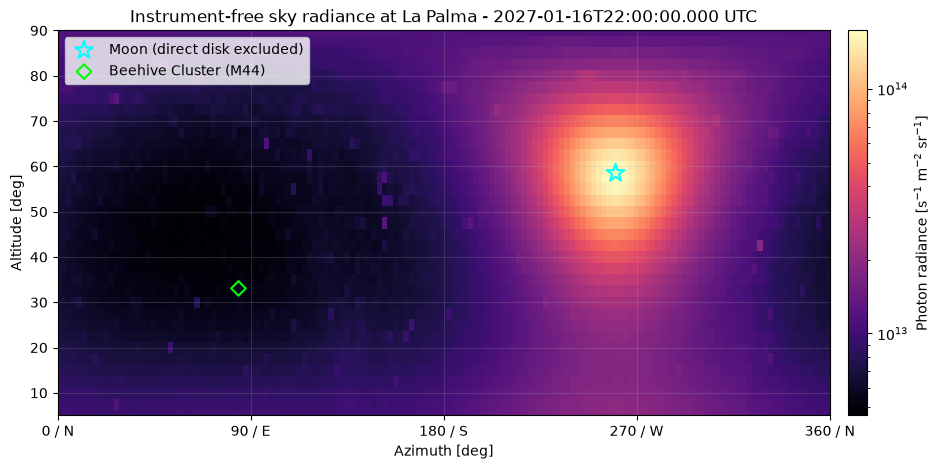

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

mesh = ax.pcolormesh(
    az_grid,
    alt_grid,
    total_radiance.value,
    shading="auto",
    cmap="magma",
    norm=LogNorm(),
)
ax.scatter(
    moon_coord.az.deg,
    moon_coord.alt.deg,
    marker="*",
    s=180,
    facecolor="none",
    edgecolor="cyan",
    linewidth=1.5,
    label="Moon (direct disk excluded)",
)
ax.scatter(
    m44_coord.az.deg,
    m44_coord.alt.deg,
    marker="D",
    s=55,
    facecolor="none",
    edgecolor="lime",
    linewidth=1.5,
    label="Beehive Cluster (M44)",
)

ax.set(
    xlim=(0, 360),
    ylim=(5, 90),
    xlabel="Azimuth [deg]",
    ylabel="Altitude [deg]",
    title=f"Instrument-free sky radiance at La Palma - {obstime.isot} UTC",
)
ax.set_xticks(
    [0, 90, 180, 270, 360],
    ["0 / N", "90 / E", "180 / S", "270 / W", "360 / N"],
)
ax.grid(alpha=0.2)
ax.legend(loc="upper left")

colorbar = fig.colorbar(mesh, ax=ax, pad=0.02)
colorbar.set_label(r"Photon radiance [s$^{-1}$ m$^{-2}$ sr$^{-1}$]")
plt.show()

## 8. Zoom in on an open-cluster target

For a target view, we make a denser rectangular AltAz grid around the Beehive
Cluster (M44). The brighter Gaia catalogue is rebinned at higher HEALPix
resolution for this zoom; the faint-star, airglow, and scattered-moonlight
components are evaluated on the same grid. This is still a sky-radiance map,
not a projection through a telescope.

In [9]:
target_half_width = 3.0
cluster_azimuth = np.linspace(
    m44_coord.az.deg - target_half_width,
    m44_coord.az.deg + target_half_width,
    81,
)
cluster_altitude = np.linspace(
    m44_coord.alt.deg - target_half_width,
    m44_coord.alt.deg + target_half_width,
    81,
)
cluster_az_grid, cluster_alt_grid = np.meshgrid(
    cluster_azimuth,
    cluster_altitude,
)
cluster_coords = SkyCoord(
    az=cluster_az_grid * u.deg,
    alt=cluster_alt_grid * u.deg,
    frame=horizon,
)
cluster_flat_coords = cluster_coords.reshape(-1)

cluster_airglow_field, _ = glow.query_direct(
    observation,
    cluster_flat_coords,
    np.zeros(cluster_flat_coords.shape),
)
cluster_airglow = (
    direct_solver.compute_rates(
        glow,
        cluster_airglow_field,
        atmosphere,
        bandpass,
    )[:, 0]
    .reshape(cluster_coords.shape)
    .to(radiance_unit, equivalencies=u.dimensionless_angles())
)

cluster_moon_components = scattered_solver.compute_rates(
    lunar_source,
    lunar_field,
    atmosphere,
    bandpass,
    cluster_coords,
)
cluster_moon = cluster_moon_components.sum(axis=-2)[..., 1].to(
    radiance_unit,
    equivalencies=u.dimensionless_angles(),
)

high_resolution_bright_star_map = fill_empty_stellar_colors(
    bright_catalog.to_map(nside=512)
)
cluster_bright_stars = direct_stellar_radiance(
    high_resolution_bright_star_map,
    cluster_coords,
)
cluster_faint_stars = direct_stellar_radiance(faint_star_map, cluster_coords)
cluster_radiance = (
    cluster_airglow + cluster_moon + cluster_bright_stars + cluster_faint_stars
)

print(f"M44 target range: {cluster_radiance.min():.3g} to {cluster_radiance.max():.3g}")

M44 target range: 4.65e+12 1 / (s sr m2) to 7.45e+13 1 / (s sr m2)


The cluster appears as a compact stellar-radiance enhancement around the marked
catalogue centre. Because the axes remain local azimuth and altitude, this map
can be compared directly with horizon coordinates while remaining independent
of a particular telescope or camera.

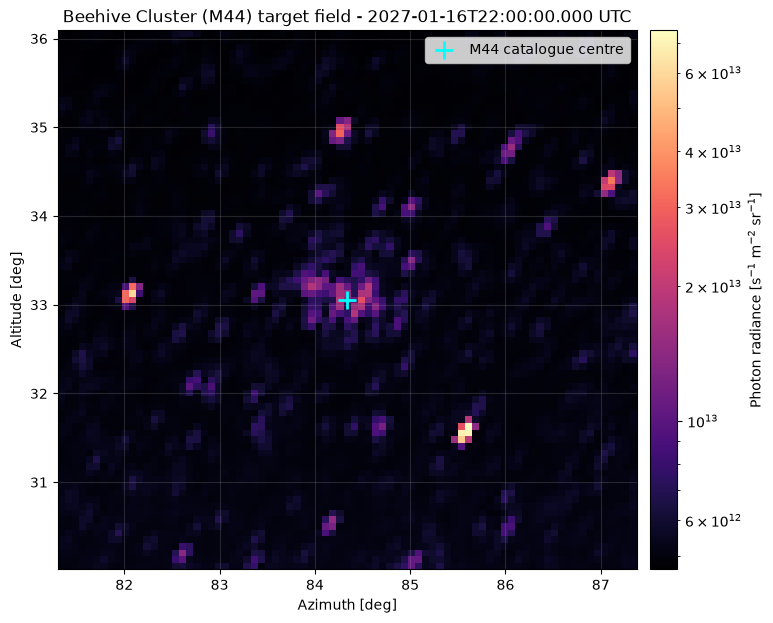

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

cluster_mesh = ax.pcolormesh(
    cluster_az_grid,
    cluster_alt_grid,
    cluster_radiance.value,
    shading="auto",
    cmap="magma",
    norm=LogNorm(),
)
ax.scatter(
    m44_coord.az.deg,
    m44_coord.alt.deg,
    marker="+",
    s=180,
    color="cyan",
    linewidth=2,
    label="M44 catalogue centre",
)
ax.set(
    xlabel="Azimuth [deg]",
    ylabel="Altitude [deg]",
    title=f"Beehive Cluster (M44) target field - {obstime.isot} UTC",
)
ax.grid(alpha=0.2)
ax.legend()

cluster_colorbar = fig.colorbar(cluster_mesh, ax=ax, pad=0.02)
cluster_colorbar.set_label(r"Photon radiance [s$^{-1}$ m$^{-2}$ sr$^{-1}$]")
plt.show()

## Interpreting and extending the result

Both maps show band-integrated **sky radiance**, not detector rates. To predict
camera counts, a later step would multiply or integrate this field with an
instrument's collecting area, angular acceptance, and wavelength-dependent
throughput. That is the projection intentionally omitted here.

Useful extensions are:

- change the bandpass to another wavelength interval or a measured filter curve,
- add zodiacal light with zodiacal.from_leinert1998(),
- select another catalogue coordinate for the target-field map,
- change the observation time to animate the lunar and stellar sky,
- increase either AltAz grid density for a smoother map.